In [17]:
from aidsorb.litmodules import PCDLit
from moxel.utils import voxels_from_file
from retnext.transforms import ClipScaleVoxels
import matplotlib.pyplot as plt
import torch

In [121]:
ckpt_path = (
    '../experiments/evaluate/benchmark/hmof/from_experiments_pretrain_early_pretrain_lightning_logs_version_0_checkpoints_best.ckpt-to_CO2-298-2.5/'
    'None/lightning_logs/version_0/checkpoints/best.ckpt'
)
model = PCDLit.load_from_checkpoint(ckpt_path).model

In [122]:
model.eval()
model.requires_grad_(False);
model.cpu();

In [157]:
#x = torch.randn(1, 1, 32, 32, 32)
x = torch.from_numpy(voxels_from_file('/home/asarikas/temp/CIFs/NU-110.cif', grid_size=32, cubic_box=30))
x = ClipScaleVoxels()(x)
x = x[None, None, ...]
x.requires_grad_(True);

In [158]:
model(x).backward()

In [159]:
sal_map = x.detach()[0, 0] * x.grad.detach()[0, 0]
sal_map = sal_map.numpy()
#plt.imshow(sal_map.sum(2), interpolation='gaussian', cmap='coolwarm')
#plt.colorbar(extend='both')

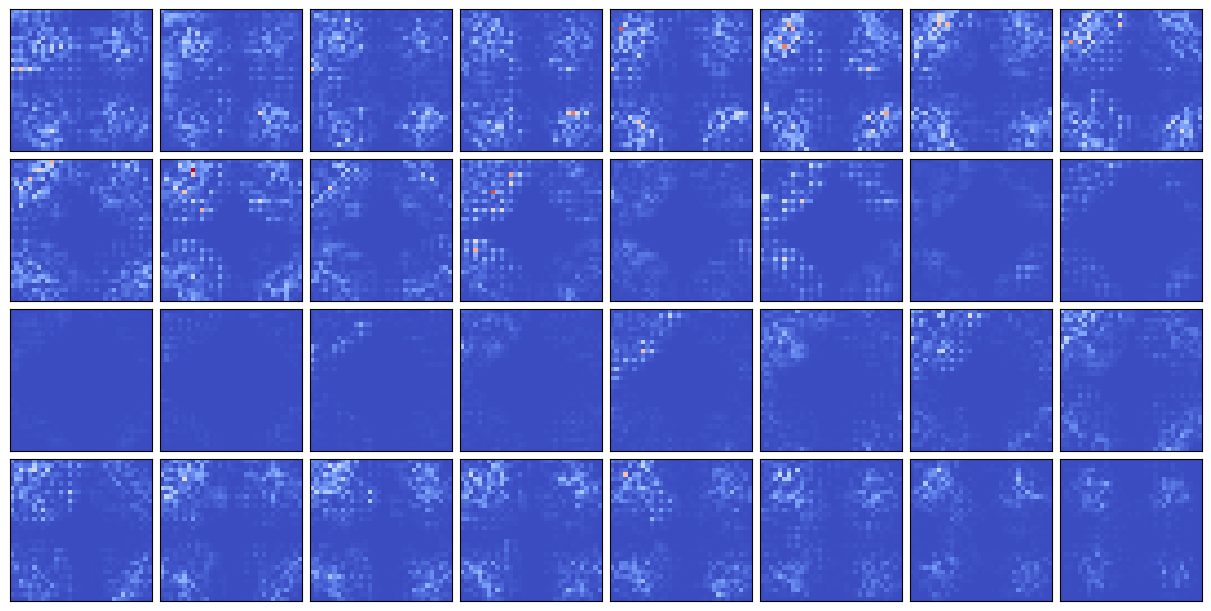

In [160]:
fig, axes = plt.subplots(4, 8, figsize=[12, 6], layout='constrained')

sal_map = np.abs(sal_map)
vmin = sal_map.min()
vmax = sal_map.max()

for i in range(32):
    ax = axes.flat[i]
    ax.set_xticks([])
    ax.set_yticks([])
    im = ax.imshow(sal_map[i], vmin=vmin, vmax=vmax, cmap='coolwarm')